In [7]:
from comp_math.bvp.model.first_order_system import FirstOrderSystem
from comp_math.bvp.model.second_order_equation import SecondOrderEquation
from comp_math.bvp.solvers.quazilinearization import QuasilinearizationSolver
from comp_math.bvp.solvers.shooting import ShootingSolver
from comp_math.linear_algebra.objects.vector import Vector

import matplotlib.pyplot as plt
import numpy as np

Решаем для y0 = 0.25
Решаем для y0 = 0.5
Решаем для y0 = 1.0
Решаем для y0 = 1.5
Решаем для y0 = 1.8
Решаем для y0 = 1.9
Решаем для y0 = 1.95


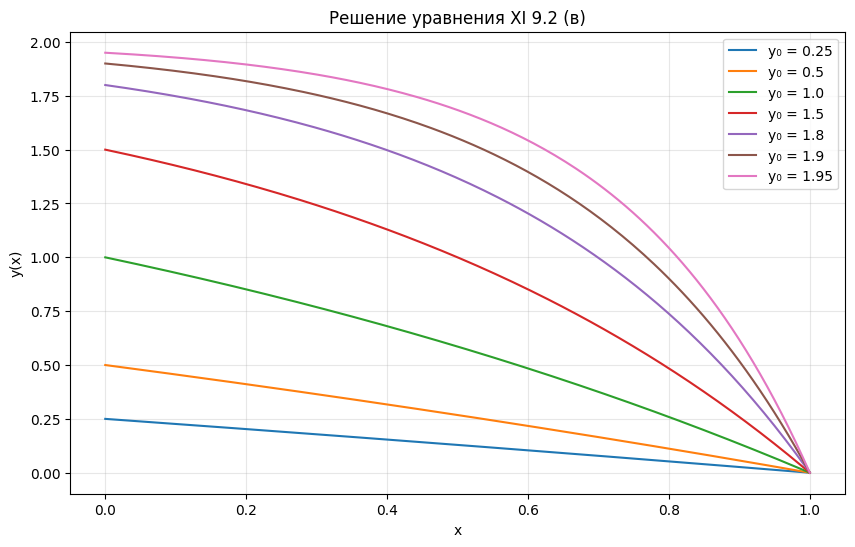

In [8]:

y0_values = [0.25, 0.5, 1.0, 1.5, 1.8, 1.9, 1.95]

def XI_92(x, y, yp):
    denominator = 1 - 0.5 * y
    return -0.5 / denominator * yp**2

plt.figure(figsize=(10, 6))

for y0 in y0_values:
    print(f"Решаем для y0 = {y0}")
    
    problem = SecondOrderEquation(
        f=XI_92,
        alpha=y0,   # y(0) = y0
        beta=0,     # y(1) = 0
        domain=(0, 1)
    )
    
    solver = QuasilinearizationSolver(problem, n_points=200)
    
    x, y = solver.solve(tol=1e-8, max_iter=50, verbose=False)
    
    plt.plot(x, y, label=f"y₀ = {y0}")

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Решение уравнения XI 9.2 (в)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Решение для y0 =  0.25
Решение для y0 =  0.5
Решение для y0 =  1.0
Решение для y0 =  1.5
Решение для y0 =  1.8
Решение для y0 =  1.9
Решение для y0 =  1.95


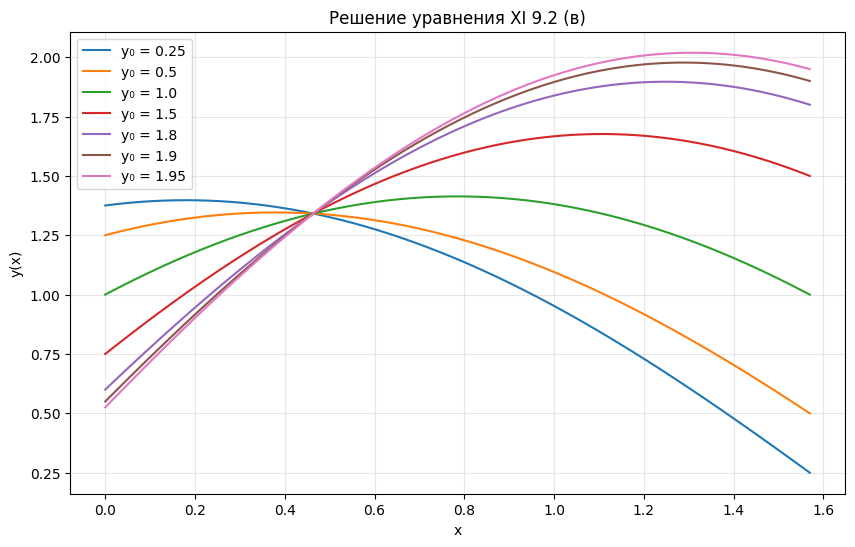

In [11]:

def system3(x, y):
    return np.array([y[1], -y[0]])

# одно начальное приближение для всех y0
a0 = [1.0, 1.0]

plt.figure(figsize=(10, 6))

for y0 in y0_values:
    print("Решение для y0 = ", y0)
    def bc3(ya, yb):
        # y'(0) + 2y(0) = 3
        # y(1) = y0
        return np.array([ya[1] + 2*ya[0] - 3, yb[0] - y0])

    problem3 = FirstOrderSystem(system3, bc3, domain=(0, np.pi / 2))
    solver3 = ShootingSolver(problem3)
    x3, y3 = solver3.solve(a0)

    plt.plot(x3, list(map(lambda yn: yn[0], y3)), label=f"y₀ = {y0}")

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Решение уравнения XI 9.2 (в)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()